# Limitations of Amplitude Encoding on Quantum Classification (AA_study)

This implementation is based on prior work by [Wang *et al.*](https://arxiv.org/abs/2503.01545).

This notebook will show a main limitation of amplitude encoding on a small dataset.

## 0. Setup and imports

In [1]:
import merlin as ml
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

## 1. Generating a simple dataset.

Here we will classify the dataset presented in figure 1 of the paper: a dataset that can not be classified by amplitude encoded-layers. Although, we will scale the dataset to have features going from 0 to 1 to obtain better results in general.

For class 1, both features follow the uniform distribution $\mathcal{U}[0,2/5]$. For class 2, both features follow the uniform distribution $\mathcal{U}[3/5,1]$.

We will generate 2000 points per class.

Here is a quick plot of the dataset.

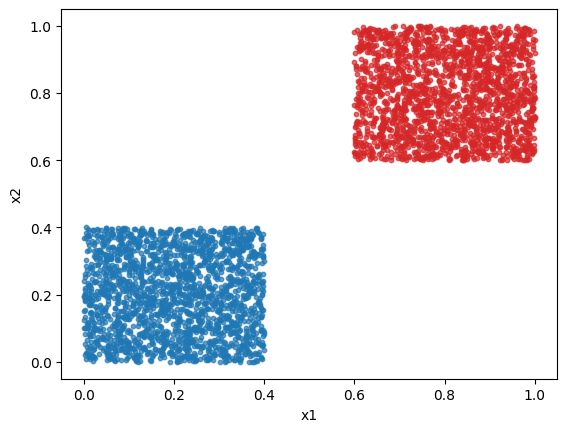

In [ ]:
class_1_x_1 = np.random.uniform(0, 2 / 5, 2000)
class_1_x_2 = np.random.uniform(0, 2 / 5, 2000)
class_1 = [[i, j] for i, j in zip(class_1_x_1, class_1_x_2)]

class_2_x_1 = np.random.uniform(3 / 5, 1, 2000)
class_2_x_2 = np.random.uniform(3 / 5, 1, 2000)
class_2 = [[i, j] for i, j in zip(class_2_x_1, class_2_x_2)]

features = np.vstack([class_1, class_2])
labels = np.concatenate([np.zeros(2000), np.ones(2000)])

features_tensor = torch.tensor(features, dtype=torch.float32)
labels_tensor = torch.tensor(labels, dtype=torch.long)

dataset = TensorDataset(features_tensor, labels_tensor)
dataloader = DataLoader(dataset, batch_size=50, shuffle=True)

# Plot
plt.scatter(class_1_x_1, class_1_x_2, s=10, color="tab:blue", alpha=0.7)
plt.scatter(class_2_x_1, class_2_x_2, s=10, color="tab:red", alpha=0.7)
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

## 2. Classify the dataset with amplitude encoding

Lets create a basic amplitude encoding model to classify this dataset.

In [3]:
circuit = ml.CircuitBuilder(n_modes=2)
for _ in range(4):
    circuit.add_entangling_layer()
qlayer = ml.QuantumLayer(
    builder=circuit,
    amplitude_encoding=True,
    n_photons=1,
)

Lets do a basic training loop to plot the loss and accuracy over the epochs.

Epoch 25 had a loss of 0.680544275790453 and accuracy of 0.5105
Epoch 50 had a loss of 0.6804427191615104 and accuracy of 0.524
Epoch 75 had a loss of 0.6804891876876354 and accuracy of 0.548
Epoch 100 had a loss of 0.6806345574557782 and accuracy of 0.51925


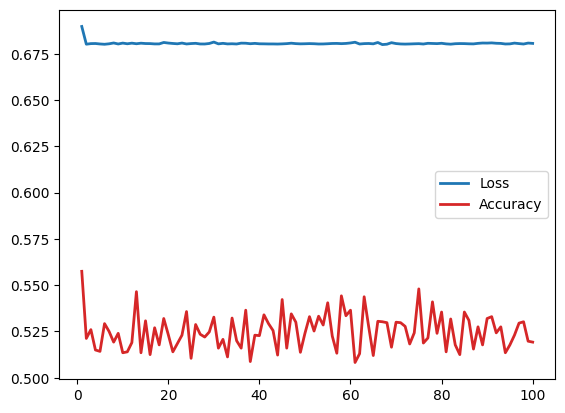

In [4]:
optimizer = torch.optim.Adam(qlayer.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()
qlayer.train()

accuracy_per_epoch = []
loss_per_epoch = []
accuracy_test_per_epoch = []
loss_test_per_epoch = []

for epoch in range(100):
    tot_loss = 0.0
    correct = 0
    total = 0
    num_batches = 0
    for features, labels in dataloader:
        optimizer.zero_grad()
        logits = qlayer(features)
        loss = criterion(logits, labels)
        loss.backward()

        optimizer.step()
        tot_loss += loss.item()
        num_batches += 1
        preds = torch.clone(logits).detach().argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total
    accuracy_per_epoch.append(accuracy)
    avg_loss = tot_loss / max(num_batches, 1)
    loss_per_epoch.append(avg_loss)
    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch + 1} had a loss of {avg_loss} and accuracy of {accuracy}")


epochs = list(range(1, 101))
plt.plot(epochs, loss_per_epoch, color="tab:blue", lw=2, label="Loss")
plt.plot(epochs, accuracy_per_epoch, color="tab:red", lw=2, label="Accuracy")
plt.legend()
plt.show()

We observe that a amplitude encoding model can not classify this simple dataset. We observe the same loss plateau at $\ln(2)$ as stated in the paper.

## 3. Classify the dataset with angle encoding

Lets classify the same dataset but, with an angle encoding-based layer.

In [5]:
circuit = ml.CircuitBuilder(n_modes=3)
circuit.add_entangling_layer()
circuit.add_angle_encoding([0, 1])
for _ in range(3):
    circuit.add_entangling_layer()
qlayer = torch.nn.Sequential(
    ml.QuantumLayer(
        input_size=2,
        builder=circuit,
        input_state=[1, 0, 0],
    ),
    ml.LexGrouping(3, 2),
)

Lets do a basic training loop to plot the loss and accuracy over the epochs.

Epoch 25 had a loss of 0.5573798418045044 and accuracy of 1.0
Epoch 50 had a loss of 0.5574306592345237 and accuracy of 1.0
Epoch 75 had a loss of 0.5571818374097347 and accuracy of 1.0
Epoch 100 had a loss of 0.5574161484837532 and accuracy of 1.0


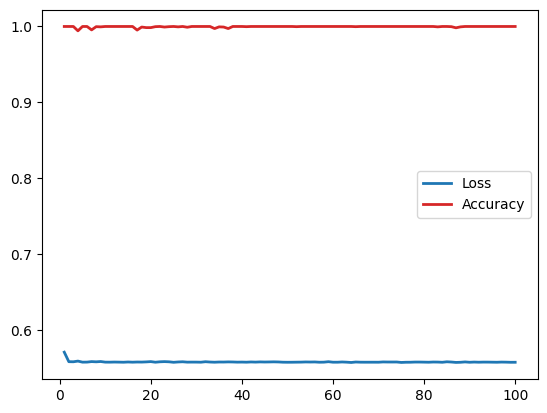

In [6]:
optimizer = torch.optim.Adam(qlayer.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()
qlayer.train()

accuracy_per_epoch = []
loss_per_epoch = []
accuracy_test_per_epoch = []
loss_test_per_epoch = []

for epoch in range(100):
    tot_loss = 0.0
    correct = 0
    total = 0
    num_batches = 0
    for features, labels in dataloader:
        optimizer.zero_grad()
        logits = qlayer(features)
        loss = criterion(logits, labels)
        loss.backward()

        optimizer.step()
        tot_loss += loss.item()
        num_batches += 1
        preds = torch.clone(logits).detach().argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total
    accuracy_per_epoch.append(accuracy)
    avg_loss = tot_loss / max(num_batches, 1)
    loss_per_epoch.append(avg_loss)
    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch + 1} had a loss of {avg_loss} and accuracy of {accuracy}")


epochs = list(range(1, 101))
plt.plot(epochs, loss_per_epoch, color="tab:blue", lw=2, label="Loss")
plt.plot(epochs, accuracy_per_epoch, color="tab:red", lw=2, label="Accuracy")
plt.legend()
plt.show()

We can see here that the angle encoding model is more suited to classify this synthetic dataset.

Even though the amplitude encoding principle uses less resources, it is not always better than a traditional angle encoding.